In [2]:
import pandas as pd
import pandas_ta as ta

df = pd.read_csv("../../data/MSFT/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
df=df[0:50000]
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
df.rename(columns = {'Gmt time':'datetime_gmt'}, inplace = True)
df['datetime_est']=pd.to_datetime(df["datetime_gmt"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')

df["Open"] = df.Open.astype(float)
df["High"] = df.High.astype(float)
df["Low"] = df.Low.astype(float)
df["Close"] = df.Close.astype(float)

# Regular hours
df.index = df['datetime_est']
df.between_time("09:30", "16:00")

df.reset_index(drop=True, inplace=True)
df = df[['datetime_est','Open','High','Low','Close','Volume']]
df

,datetime_est,Open,High,Low,Close,Volume
0,2022-09-01 09:30:00-04:00,259.337,259.547,257.896,257.927,2.026800
1,2022-09-01 09:35:00-04:00,257.967,258.957,257.926,258.576,2.226000
2,2022-09-01 09:40:00-04:00,258.547,259.377,258.396,258.737,2.271600
3,2022-09-01 09:45:00-04:00,258.687,259.277,258.466,258.766,2.744400
4,2022-09-01 09:50:00-04:00,258.726,259.147,258.496,259.087,2.450400
...,...,...,...,...,...,...
12064,2023-06-16 15:35:00-04:00,344.027,344.177,343.686,343.926,0.000001
12065,2023-06-16 15:40:00-04:00,343.917,343.966,343.496,343.557,0.000001
12066,2023-06-16 15:45:00-04:00,343.566,344.017,343.506,343.766,0.000001
12067,2023-06-16 15:50:00-04:00,343.746,343.797,342.616,342.737,0.000001


In [4]:
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from IPython import display
from IPython.display import HTML
pd.set_option('mode.chained_assignment', None)

[ 2  5 13 16]
[ 1  4  9 14]
1


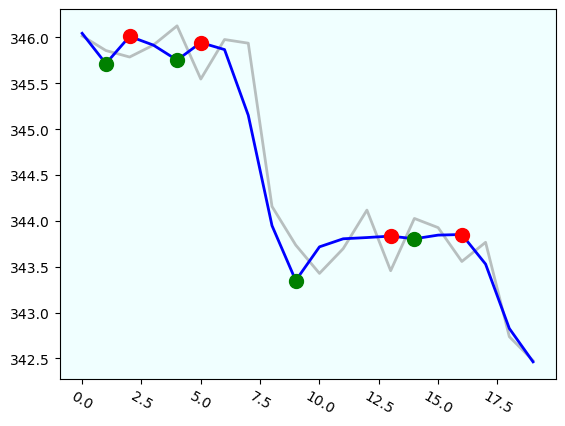

,datetime_est,Open,High,Low,Close,Volume,atr,close_smooth
0,2023-06-16 13:20:00-04:00,345.926,346.087,345.766,346.016,7.668000e-07,NaN,346.044748
1,2023-06-16 13:25:00-04:00,346.017,346.307,345.776,345.857,8.946000e-07,NaN,345.714325
2,2023-06-16 13:30:00-04:00,345.856,346.007,345.746,345.786,6.723000e-07,NaN,346.011703
3,2023-06-16 13:35:00-04:00,345.776,345.937,345.557,345.916,7.605000e-07,NaN,345.916196
4,2023-06-16 13:40:00-04:00,345.907,346.136,345.596,346.126,8.190000e-07,NaN,345.752696
5,2023-06-16 13:45:00-04:00,346.126,346.187,345.396,345.546,9.333000e-07,NaN,345.943539
6,2023-06-16 13:50:00-04:00,345.537,346.056,345.406,345.977,7.317000e-07,NaN,345.867355
7,2023-06-16 13:55:00-04:00,345.977,346.016,345.686,345.937,7.803000e-07,NaN,345.151151
8,2023-06-16 15:00:00-04:00,344.146,344.316,343.776,344.157,1.261800e-06,NaN,343.947834
9,2023-06-16 15:05:00-04:00,344.156,344.266,343.607,343.736,1.023300e-06,NaN,343.348918


In [35]:

df2=df[-20:]
df2.reset_index(drop=True, inplace=True)

atr_window = 7
smooth_window_lenght = 10
polyorder = 6  # Must be less than window_lenght
distance = 3
width = 3

## Take the rolling atr so the yaxis doesn't shake too much 
df2["close_smooth"] = savgol_filter(df2.Close, smooth_window_lenght, polyorder)

# PLOT #
fig, ax = plt.subplots()
plt.xticks(rotation=-30)
price, = ax.plot(df2.index, df2.Close, c='grey', lw=2, alpha=0.5, zorder=5)
price_smooth, = ax.plot(df2.index, df2.close_smooth, c='b', lw=2, zorder=5)

peaks_idx, _ = find_peaks(df2.close_smooth)
troughs_idx, _ = find_peaks(-1*df2.close_smooth)

'''
Check if we are on a up trend
'''
up_run_length = 0
up_run = True
while up_run:
    if 2 + up_run_length > len(peaks_idx) or 2 + up_run_length > len(troughs_idx):
        break

    peaks_index1 = peaks_idx[-1 - up_run_length]
    peaks_index2 = peaks_idx[-2 - up_run_length]
    
    peaks1 = df2.close_smooth.iloc[peaks_idx[-1 - up_run_length]]
    peaks2 = df2.close_smooth.iloc[peaks_idx[-2 - up_run_length]]

    troughs_index1 = troughs_idx[-1 - up_run_length]
    troughs_index2 = troughs_idx[-2 - up_run_length]
    
    troughs1 = df2.close_smooth.iloc[troughs_idx[-1 - up_run_length]]
    troughs2 = df2.close_smooth.iloc[troughs_idx[-2 - up_run_length]]
    
    if peaks1 > peaks2 and troughs1 > troughs2:
        up_run_length += 1
    else:
        up_run = False 

print(peaks_idx)
print(troughs_idx)
print(up_run_length)

peaks, = ax.plot(df2.index[peaks_idx], df2.close_smooth.iloc[peaks_idx], \
                 c="r", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

troughs, = ax.plot(df2.index[troughs_idx], df2.close_smooth.iloc[troughs_idx], \
                   c="g", linestyle='None', markersize = 10.0, marker = "o", zorder=10)

'''
Set background color
'''
if up_run_length > 0:
    ax.set_facecolor('azure')  
else:
    ax.set_facecolor("white")
    
plt.show()
df2